# 05. KIỂM ĐỊNH THỐNG KÊ VÀ PHÂN TÍCH BỔ SUNG

**Mục đích:** tái lập các con số thống kê trích trong `docs/key_insights.md` và `report/project_report.md`: p-value (ANOVA, Kruskal-Wallis), R², phân rã Revenue = Orders × AOV theo năm, tập trung khách hàng, so sánh khuyến mãi (Zomato).

**Vì sao cần:** notebook 01b/02b chỉ so sánh trung bình bằng biểu đồ. Cột này cao hơn cột kia **chưa đủ** để kết luận khác biệt là thật hay do ngẫu nhiên; kiểm định thống kê trả lời câu đó.

**Input:** `data/clean/chowdeck_clean.csv`, `data/clean/zomato_clean.csv` (từ 01a, 02a).
**Output:** bảng in ra màn hình, `outputs/charts/chart_distribution_chowdeck.png`, `outputs/kpi_summary/statistical_tests_summary.csv`.

**Đọc nhanh:** *p-value* = xác suất thấy khác biệt lớn như vậy chỉ do ngẫu nhiên (p < 0,05 → có ý nghĩa thống kê; p lớn → có thể chỉ là ngẫu nhiên). *eta² / R²* = phần biến thiên của giá trị đơn mà yếu tố giải thích được. Mọi kết quả chỉ là **mối liên hệ**, không phải nhân quả.

In [1]:
import warnings
import pandas as pd, numpy as np
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ModelWarning
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', ModelWarning)   # statsmodels bật lại cảnh báo này khi import
pd.set_option('display.max_columns', 50); pd.set_option('display.width', 200)
sns.set_style('whitegrid')

try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd().resolve().parent
CHOW_PATH = BASE_DIR / 'data' / 'clean' / 'chowdeck_clean.csv'
ZOM_PATH = BASE_DIR / 'data' / 'clean' / 'zomato_clean.csv'
CHARTS_DIR = BASE_DIR / 'outputs' / 'charts'; KPI_DIR = BASE_DIR / 'outputs' / 'kpi_summary'
CHARTS_DIR.mkdir(parents=True, exist_ok=True); KPI_DIR.mkdir(parents=True, exist_ok=True)

results = []
def log(dataset, analysis, metric, value, note=''):
    results.append({'dataset': dataset, 'analysis': analysis, 'metric': metric, 'value': value, 'note': note})
print('BASE_DIR:', BASE_DIR)

BASE_DIR: D:\Data Analyst\restaurant-revenue-da-project\restaurant-revenue-da-project


## Hàm hỗ trợ
- `eta_squared` = biến thiên giữa các nhóm / tổng biến thiên.
- `compare_groups` chạy **ANOVA** (so sánh trung bình nhiều nhóm) và **Kruskal-Wallis** (không cần giả định phân phối chuẩn). Chạy cả hai để kết luận không phụ thuộc giả định.

In [2]:
def eta_squared(df, group_col, value_col):
    gm = df[value_col].mean()
    ss_total = ((df[value_col] - gm) ** 2).sum()
    gs = df.groupby(group_col)[value_col].agg(['count', 'mean'])
    return (gs['count'] * (gs['mean'] - gm) ** 2).sum() / ss_total

def compare_groups(df, group_col, value_col='revenue'):
    groups = [g[value_col].values for _, g in df.groupby(group_col) if len(g) > 1]
    return {'n_groups': len(groups), 'anova_p': stats.f_oneway(*groups).pvalue,
            'kruskal_p': stats.kruskal(*groups).pvalue, 'eta2': eta_squared(df, group_col, value_col)}

def verdict(p, alpha=0.05):
    return 'CÓ khác biệt có ý nghĩa' if p < alpha else 'KHÔNG có khác biệt có ý nghĩa'

# PHẦN A: CHOWDECK

In [3]:
chow = pd.read_csv(CHOW_PATH)
print('Shape:', chow.shape, '| shop:', chow['Shop Name'].nunique(), '| tài khoản:', chow['Account'].nunique())
valid = chow[chow['time_sequence_valid']]; invalid = chow[~chow['time_sequence_valid']]
print('Đơn timestamp hợp lệ:', len(valid), '| lỗi:', len(invalid))

Shape: (3061, 33) | shop: 15 | tài khoản: 181
Đơn timestamp hợp lệ: 2191 | lỗi: 870


## A1. Phân phối giá trị đơn và Rating (EDA đơn biến)
Notebook EDA trước chỉ so sánh trung bình. Cần xem *hình dạng* dữ liệu: có lệch phải không? Rating nhận những giá trị nào? Đây cũng là lý do dùng **median** ở phần ML.

count     3061.0
mean      8241.0
std       7897.0
min       1000.0
25%       4000.0
50%       5000.0
75%      10500.0
max      60000.0
Name: revenue, dtype: float64

Skewness revenue: 2.45 (>0: lệch phải)

Tần suất Rating:
Rating
3.0     859
3.5     358
4.0    1026
4.5     191
5.0     627
Name: count, dtype: int64


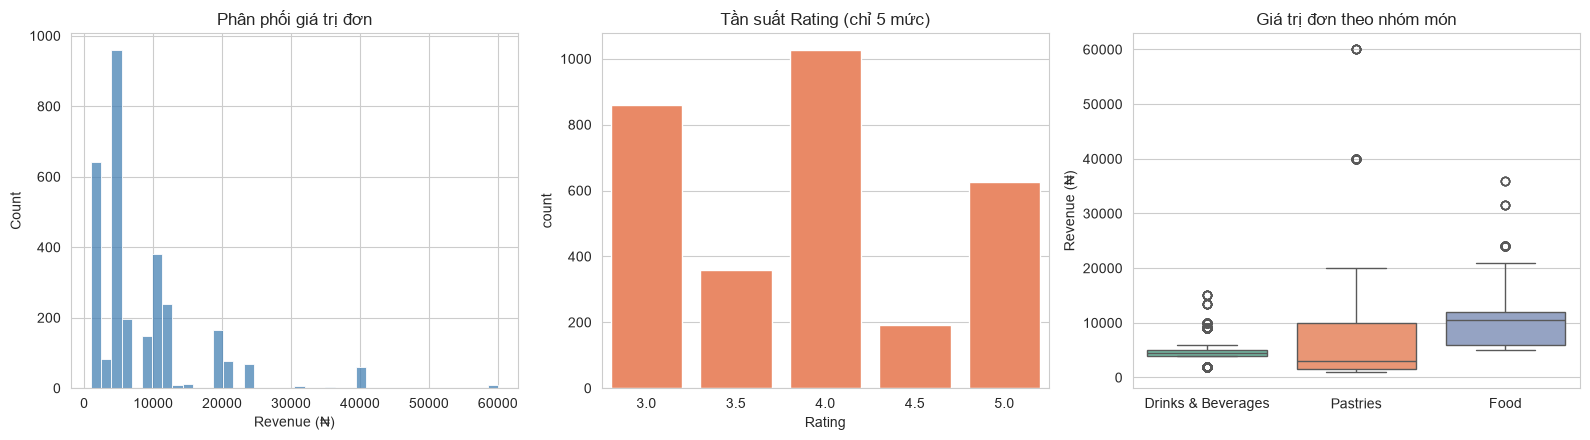

In [4]:
print(chow['revenue'].describe().round(0))
print('\nSkewness revenue:', round(chow['revenue'].skew(), 2), '(>0: lệch phải)')
print('\nTần suất Rating:'); print(chow['Rating'].value_counts().sort_index())

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(chow['revenue'], bins=40, ax=ax[0], color='steelblue'); ax[0].set_title('Phân phối giá trị đơn'); ax[0].set_xlabel('Revenue (₦)')
sns.countplot(x='Rating', data=chow, ax=ax[1], color='coral'); ax[1].set_title('Tần suất Rating (chỉ 5 mức)')
sns.boxplot(x='Order Category', y='revenue', data=chow, ax=ax[2], palette='Set2'); ax[2].set_title('Giá trị đơn theo nhóm món'); ax[2].set_xlabel(''); ax[2].set_ylabel('Revenue (₦)')
plt.tight_layout(); plt.savefig(CHARTS_DIR / 'chart_distribution_chowdeck.png', dpi=120, bbox_inches='tight'); plt.show(); plt.close()
log('Chowdeck','Phân phối','skewness_revenue', round(chow['revenue'].skew(),3)); log('Chowdeck','Phân phối','median_revenue', float(chow['revenue'].median()))

## A2. Giá trị đơn có khác nhau giữa các nhóm không? (ANOVA và Kruskal-Wallis)
Trả lời BQ1, 2, 5, 6. H0: trung bình giá trị đơn bằng nhau giữa các nhóm; p < 0,05 → bác bỏ H0.

In [5]:
factors = [('Order Category','Nhóm món'),('Shop Name','Nhà hàng'),('Delivery Location','Khu vực giao'),
           ('order_dayofweek','Thứ trong tuần'),('order_hour','Giờ đặt'),('order_year','Năm')]
rows = []
for col, label in factors:
    r = compare_groups(chow, col)
    rows.append({'Yếu tố':label,'Số nhóm':r['n_groups'],'ANOVA p':r['anova_p'],'Kruskal p':r['kruskal_p'],'eta² (%)':r['eta2']*100,'Kết luận':verdict(r['anova_p'])})
    log('Chowdeck','ANOVA giá trị đơn',f'{label} - p',r['anova_p']); log('Chowdeck','Kruskal giá trị đơn',f'{label} - p',r['kruskal_p']); log('Chowdeck','eta2 giá trị đơn',f'{label} (%)',r['eta2']*100)
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

        Yếu tố  Số nhóm  ANOVA p  Kruskal p  eta² (%)                      Kết luận
      Nhóm món        3   0.0000     0.0000    9.0009       CÓ khác biệt có ý nghĩa
      Nhà hàng       15   0.0000     0.0000    9.2059       CÓ khác biệt có ý nghĩa
  Khu vực giao       10   0.5529     0.8226    0.2555 KHÔNG có khác biệt có ý nghĩa
Thứ trong tuần        7   0.4953     0.3693    0.1761 KHÔNG có khác biệt có ý nghĩa
       Giờ đặt       24   0.5641     0.2641    0.6958 KHÔNG có khác biệt có ý nghĩa
           Năm        3   0.4407     0.8983    0.0536 KHÔNG có khác biệt có ý nghĩa


Chỉ **nhóm món** (và `Nhà hàng`) có p nhỏ. ⚠️ `Nhà hàng` nhỏ **chỉ vì** mỗi shop thuộc đúng một nhóm món; mục A3 tách hiệu ứng này.

## A3. Nhà hàng có khác nhau khi so trong CÙNG một nhóm món không?
Chạy ANOVA giữa các shop **bên trong từng nhóm món** để tránh nhầm hiệu ứng nhóm món với hiệu ứng nhà hàng (liên quan *Simpson's paradox*).

In [6]:
rows = []
for cat, g in chow.groupby('Order Category'):
    r = compare_groups(g, 'Shop Name'); aov = g.groupby('Shop Name')['revenue'].mean()
    rows.append({'Nhóm món':cat,'Số shop':r['n_groups'],'ANOVA p':r['anova_p'],'Kruskal p':r['kruskal_p'],'AOV thấp nhất':aov.min(),'AOV cao nhất':aov.max(),'Kết luận':verdict(r['anova_p'])})
    log('Chowdeck','Shop trong cùng nhóm món',f'{cat} - ANOVA p',r['anova_p'])
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x: f'{x:,.3f}' if x<100 else f'{x:,.0f}'))

          Nhóm món  Số shop  ANOVA p  Kruskal p  AOV thấp nhất  AOV cao nhất                      Kết luận
Drinks & Beverages        5    0.702      0.812          5,103         5,431 KHÔNG có khác biệt có ý nghĩa
              Food        5    0.666      0.497         10,695        11,399 KHÔNG có khác biệt có ý nghĩa
          Pastries        5    0.687      0.627          7,720         9,098 KHÔNG có khác biệt có ý nghĩa


## A4. Khu vực, thứ, giờ, Rating khi ĐÃ kiểm soát nhóm món
Hồi quy OLS `revenue ~ nhóm món + khu vực + thứ + giờ + Rating`, rồi ANOVA loại II cho đóng góp riêng của từng yếu tố. Kèm **R²** của từng yếu tố đứng riêng.

> Mô hình `nhóm món + shop` là *rank-deficient* vì mỗi shop nằm lồng trong một nhóm món. R² vẫn đúng; chỉ là không tách được hệ số riêng của từng shop.

In [7]:
m = chow.rename(columns={'Order Category':'cat','Shop Name':'shop','Delivery Location':'loc','order_dayofweek':'dow','order_hour':'hour','Rating':'rating','Unit Price':'unit_price','Quantity':'qty'})
r2 = {'Nhóm món':'revenue ~ C(cat)','Nhóm món + Shop':'revenue ~ C(cat) + C(shop)','Khu vực':'revenue ~ C(loc)','Thứ':'revenue ~ C(dow)',
      'Giờ':'revenue ~ C(hour)','Rating':'revenue ~ rating','Đơn giá + Số lượng':'revenue ~ unit_price + qty'}
print('R² (tỷ lệ biến thiên giá trị đơn được giải thích):')
for k, f in r2.items():
    v = smf.ols(f, m).fit().rsquared; print(f'  {k:20s}: {v*100:6.2f}%'); log('Chowdeck','R2 giá trị đơn',k+' (%)',v*100)

full = smf.ols('revenue ~ C(cat) + C(loc) + C(dow) + C(hour) + rating', m).fit()
tab = sm.stats.anova_lm(full, typ=2)
print('\nANOVA loại II (đã kiểm soát nhóm món):'); print(tab[['sum_sq','df','F','PR(>F)']].round(4).to_string())
for name in ['C(cat)','C(loc)','C(dow)','C(hour)','rating']:
    log('Chowdeck','ANOVA loại II (kiểm soát nhóm món)',name+' - p',float(tab.loc[name,'PR(>F)']))

R² (tỷ lệ biến thiên giá trị đơn được giải thích):
  Nhóm món            :   9.00%
  Nhóm món + Shop     :   9.19%
  Khu vực             :   0.26%
  Thứ                 :   0.18%
  Giờ                 :   0.70%
  Rating              :   0.02%
  Đơn giá + Số lượng  :  88.78%

ANOVA loại II (đã kiểm soát nhóm món):
                sum_sq      df         F  PR(>F)
C(cat)    1.680123e+10     2.0  147.4727  0.0000
C(loc)    3.957718e+08     9.0    0.7720  0.6426
C(dow)    2.560445e+08     6.0    0.7491  0.6101
C(hour)   9.171858e+08    23.0    0.7001  0.8503
rating    1.529029e+07     1.0    0.2684  0.6044
Residual  1.719739e+11  3019.0       NaN     NaN


Nhóm món giải thích ≈ 9%; thêm Shop gần như không đổi. Khu vực, thứ, giờ, Rating mỗi yếu tố dưới 1%, và sau khi kiểm soát nhóm món đều p > 0,6. `Đơn giá + Số lượng` ≈ 89% là hiển nhiên vì `Sub Total = Đơn giá × Số lượng`.

## A5. Tương quan Rating, thời gian và giá trị đơn
Hai cấp: **nhà hàng** (15 điểm) và **đơn hàng** (3.061 điểm). Dùng **Pearson** (đường thẳng) và **Spearman** (đơn điệu, hợp với biến ít mức như Rating).

In [8]:
shop = chow.groupby('Shop Name').agg(orders=('revenue','count'), aov=('revenue','mean'), rating=('Rating','mean'))
for t in ['orders','aov']:
    r,p = stats.pearsonr(shop['rating'], shop[t]); rho,ps = stats.spearmanr(shop['rating'], shop[t])
    print(f'Cấp shop (n={len(shop)}): Rating vs {t:6s} | Pearson r={r:+.3f} (p={p:.3f}) | Spearman={rho:+.3f} (p={ps:.3f})')
    log('Chowdeck','Tương quan cấp shop',f'Rating vs {t} - Pearson r',r); log('Chowdeck','Tương quan cấp shop',f'Rating vs {t} - p',p)
print('→ Với n = 15, |r| phải > ~0,51 mới có ý nghĩa thống kê.\n')

r,p = stats.pearsonr(chow['Rating'], chow['revenue']); rho,ps = stats.spearmanr(chow['Rating'], chow['revenue'])
print(f'Cấp đơn: Rating vs revenue | Pearson r={r:+.3f} (p={p:.3f}) | Spearman={rho:+.3f} (p={ps:.3f})')
log('Chowdeck','Tương quan cấp đơn','Rating vs revenue - Pearson r',r); log('Chowdeck','Tương quan cấp đơn','Rating vs revenue - p',p)

out=[]
for col in ['delivery_time_min','prep_time_min','delay_min']:
    a=chow[col].corr(chow['Rating']); b=valid[col].corr(valid['Rating'])
    out.append({'Biến':col,'Toàn bộ 3.061 đơn':a,f'Chỉ đơn hợp lệ ({len(valid)})':b})
    log('Chowdeck','Tương quan thời gian vs Rating',col+' - toàn bộ',a); log('Chowdeck','Tương quan thời gian vs Rating',col+' - đơn hợp lệ',b)
print('\nTương quan với Rating (Pearson r):'); print(pd.DataFrame(out).round(3).to_string(index=False))

Cấp shop (n=15): Rating vs orders | Pearson r=+0.052 (p=0.853) | Spearman=+0.118 (p=0.675)
Cấp shop (n=15): Rating vs aov    | Pearson r=+0.137 (p=0.626) | Spearman=+0.032 (p=0.909)
→ Với n = 15, |r| phải > ~0,51 mới có ý nghĩa thống kê.

Cấp đơn: Rating vs revenue | Pearson r=+0.013 (p=0.460) | Spearman=+0.019 (p=0.297)

Tương quan với Rating (Pearson r):
             Biến  Toàn bộ 3.061 đơn  Chỉ đơn hợp lệ (2191)
delivery_time_min              0.046                  0.022
    prep_time_min             -0.017                 -0.018
        delay_min              0.101                  0.062


## A6. Phân rã Revenue = Orders × AOV theo năm
Khi doanh thu đổi giữa các năm, **số đơn** hay **AOV** là nguyên nhân chính?

In [9]:
yearly = chow.groupby('order_year').agg(orders=('revenue','count'), revenue=('revenue','sum'), aov=('revenue','mean')).round(0)
print(yearly.to_string(), '\n')
for a,b in [(2023,2024),(2024,2025),(2023,2025)]:
    pct = {k:(yearly.loc[b,k]/yearly.loc[a,k]-1)*100 for k in ['revenue','orders','aov']}
    print(f'{a} → {b}: Revenue {pct["revenue"]:+.1f}% | Orders {pct["orders"]:+.1f}% | AOV {pct["aov"]:+.1f}%')
    for k,v in pct.items(): log('Chowdeck','Phân rã theo năm',f'{a}->{b} {k} (%)',v)
p_year = compare_groups(chow,'order_year')['anova_p']
print(f'\nANOVA giá trị đơn giữa các năm: p = {p_year:.3f} → {verdict(p_year)}')
print('⇒ Biến động giữa các năm có thể chỉ là dao động ngẫu nhiên, không nên gọi là "xu hướng".')

            orders  revenue     aov
order_year                         
2023          1067  9041000  8473.0
2024           983  7895500  8032.0
2025          1011  8289500  8199.0 



2023 → 2024: Revenue -12.7% | Orders -7.9% | AOV -5.2%
2024 → 2025: Revenue +5.0% | Orders +2.8% | AOV +2.1%
2023 → 2025: Revenue -8.3% | Orders -5.2% | AOV -3.2%

ANOVA giá trị đơn giữa các năm: p = 0.441 → KHÔNG có khác biệt có ý nghĩa
⇒ Biến động giữa các năm có thể chỉ là dao động ngẫu nhiên, không nên gọi là "xu hướng".


## A7. Tập trung khách hàng và shop (Pareto)
Dataset không có ngày đăng ký nên chỉ đo mức tập trung, không phân tích khách mới/quay lại.

In [10]:
acc = chow.groupby('Account')['revenue'].agg(orders='count', revenue='sum').sort_values('revenue', ascending=False)
n10 = max(1, len(acc)//10); share = acc['revenue'].head(n10).sum()/acc['revenue'].sum()*100
print(f'{len(acc)} tài khoản | số đơn trung vị/tài khoản: {acc["orders"].median():.0f} | top 10% ({n10} tài khoản) tạo {share:.1f}% doanh thu')
log('Chowdeck','Tập trung khách hàng','top10% accounts share (%)',share)
sr = chow.groupby('Shop Name')['revenue'].sum().sort_values(ascending=False); t3 = sr.head(3).sum()
print(f'Top 3 shop: {t3:,.0f} ₦ = {t3/sr.sum()*100:.1f}% doanh thu (khớp DAX % Revenue Top3 Shops)')
log('Chowdeck','Tập trung theo shop','top3 shops share (%)',t3/sr.sum()*100)

181 tài khoản | số đơn trung vị/tài khoản: 11 | top 10% (18 tài khoản) tạo 42.5% doanh thu
Top 3 shop: 6,612,500 ₦ = 26.2% doanh thu (khớp DAX % Revenue Top3 Shops)


## A8. Độ trễ giao hàng: chỉ tính trên đơn timestamp hợp lệ
Ở đơn timestamp sai thứ tự, `delay_min` gần như luôn bằng 0 nên không phản ánh độ trễ thật.

In [11]:
print(f'Đơn timestamp LỖI ({len(invalid)}): delay_min == 0 ở {(invalid["delay_min"]==0).mean()*100:.1f}% dòng')
print(f'% đơn trễ - toàn bộ ({len(chow)}): {(chow["delay_min"]>0).mean()*100:.1f}% (bị pha loãng)')
print(f'% đơn trễ - chỉ đơn hợp lệ ({len(valid)}): {(valid["delay_min"]>0).mean()*100:.1f}%')
print(f'Trễ TB (đơn hợp lệ): {valid["delay_min"].mean():.1f} phút | trung vị: {valid["delay_min"].median():.0f}')
log('Chowdeck','Độ trễ','pct_late_all (%)',(chow['delay_min']>0).mean()*100); log('Chowdeck','Độ trễ','pct_late_valid_only (%)',(valid['delay_min']>0).mean()*100); log('Chowdeck','Độ trễ','avg_delay_valid_only (min)',valid['delay_min'].mean())
late = valid[valid['delay_min']>0]['Rating']; ontime = valid[valid['delay_min']<=0]['Rating']
p_u = stats.mannwhitneyu(late, ontime).pvalue
print(f'\nRating TB: đơn trễ {late.mean():.2f} (n={len(late)}) | không trễ {ontime.mean():.2f} (n={len(ontime)}) | Mann-Whitney p={p_u:.4f}')
print('⇒ Trái trực giác (đơn trễ Rating cao hơn): không dùng làm insight; cần kiểm tra cách ghi nhận dữ liệu.')
log('Chowdeck','Bất thường','rating_late vs ontime',f'{late.mean():.2f} vs {ontime.mean():.2f}',f'p={p_u:.4f}')
print(f'Rating TB: đơn hợp lệ {valid["Rating"].mean():.2f} | đơn lỗi {invalid["Rating"].mean():.2f}')

Đơn timestamp LỖI (870): delay_min == 0 ở 99.4% dòng
% đơn trễ - toàn bộ (3061): 42.7% (bị pha loãng)
% đơn trễ - chỉ đơn hợp lệ (2191): 59.6%
Trễ TB (đơn hợp lệ): 5.5 phút | trung vị: 3

Rating TB: đơn trễ 4.10 (n=1306) | không trễ 3.82 (n=885) | Mann-Whitney p=0.0000
⇒ Trái trực giác (đơn trễ Rating cao hơn): không dùng làm insight; cần kiểm tra cách ghi nhận dữ liệu.
Rating TB: đơn hợp lệ 3.99 | đơn lỗi 3.66


# PHẦN B: ZOMATO

In [12]:
zom = pd.read_csv(ZOM_PATH); zom['has_discount'] = zom['has_discount'].astype(bool)
dl = zom[zom['Order Status']=='Delivered'].copy()
print('Tổng đơn:', len(zom), '| Delivered:', len(dl))
sh = (dl['Restaurant name'].value_counts(normalize=True)*100).round(1); print('% số đơn theo nhà hàng:'); print(sh.to_string())
rv = (dl.groupby('Restaurant name')['Total'].sum()/dl['Total'].sum()*100).round(1).sort_values(ascending=False); print('\n% doanh thu theo nhà hàng:'); print(rv.to_string())
log('Zomato','Tập trung nhà hàng','top1 orders (%)',float(sh.iloc[0]),sh.index[0]); log('Zomato','Tập trung nhà hàng','top1 revenue (%)',float(rv.iloc[0]),rv.index[0])

Tổng đơn: 21321 | Delivered: 21131
% số đơn theo nhà hàng:
Restaurant name
Aura Pizzas             68.2
Swaad                   29.7
Dilli Burger Adda        1.1
Tandoori Junction        0.7
The Chicken Junction     0.2
Masala Junction          0.1

% doanh thu theo nhà hàng:
Restaurant name
Aura Pizzas             73.8
Swaad                   24.4
Tandoori Junction        0.9
Dilli Burger Adda        0.7
Masala Junction          0.1
The Chicken Junction     0.1


## B1. Khuyến mãi và giá trị đơn
`Total` = khách **trả** (đã trừ giảm giá, dùng làm Revenue/AOV); `Bill subtotal` = hóa đơn **gốc**. **Mann-Whitney U** so sánh hai nhóm, không cần phân phối chuẩn.

In [13]:
g = dl.groupby('has_discount').agg(orders=('Total','count'), aov_total=('Total','mean'), bill_subtotal=('Bill subtotal','mean'))
g['share_orders_%'] = g['orders']/g['orders'].sum()*100
print(g.round(1).to_string()); print(f'\n% đơn có khuyến mãi: {dl["has_discount"].mean()*100:.1f}%')
print(f'AOV (Total) có KM so với không KM: {(g.loc[True,"aov_total"]/g.loc[False,"aov_total"]-1)*100:+.1f}%')
for col in ['Total','Bill subtotal']:
    p = stats.mannwhitneyu(dl.loc[dl.has_discount,col], dl.loc[~dl.has_discount,col]).pvalue
    print(f'Mann-Whitney {col:14s}: p = {p:.2e}'); log('Zomato','Mann-Whitney có vs không KM',col+' - p',p)
for k,v in [('pct_orders_with_discount (%)',dl['has_discount'].mean()*100),('aov_total_with',g.loc[True,'aov_total']),('aov_total_without',g.loc[False,'aov_total']),('bill_subtotal_with',g.loc[True,'bill_subtotal']),('bill_subtotal_without',g.loc[False,'bill_subtotal'])]:
    log('Zomato','Khuyến mãi',k,v)
w = dl[dl['has_discount']].copy(); w['pct'] = w['total_discount']/w['Bill subtotal']*100
print('\nTiền giảm / hóa đơn gốc (%), đơn có KM:'); print(w['pct'].describe().round(1).to_string())
rr = dl['total_discount'].corr(dl['Bill subtotal']); print(f'\ncorr(total_discount, Bill subtotal) = {rr:.3f}')
print('⇒ Tiền giảm là tỷ lệ của hóa đơn nên tương quan này một phần mang tính CƠ HỌC, không phải bằng chứng khuyến mãi làm hóa đơn tăng.')
log('Zomato','Tương quan','corr(total_discount, Bill subtotal)',rr)

              orders  aov_total  bill_subtotal  share_orders_%
has_discount                                                  
False           8217      710.0          676.1            38.9
True           12914      665.1          797.0            61.1

% đơn có khuyến mãi: 61.1%
AOV (Total) có KM so với không KM: -6.3%
Mann-Whitney Total         : p = 7.87e-30
Mann-Whitney Bill subtotal : p = 2.30e-105

Tiền giảm / hóa đơn gốc (%), đơn có KM:
count    12914.0
mean        22.5
std         12.5
min          1.9
25%         13.5
50%         17.7
75%         26.7
max         55.0

corr(total_discount, Bill subtotal) = 0.504
⇒ Tiền giảm là tỷ lệ của hóa đơn nên tương quan này một phần mang tính CƠ HỌC, không phải bằng chứng khuyến mãi làm hóa đơn tăng.


## B2. So sánh trong từng nhà hàng
Gộp nhiều nhà hàng có thể gây nhầm (một nhà hàng chi phối). Cột `n` cho biết cỡ mẫu; nhà hàng ít đơn thì không đáng tin.

In [14]:
rows=[]
for name, gr in dl.groupby('Restaurant name'):
    a=gr[gr.has_discount]['Bill subtotal']; b=gr[~gr.has_discount]['Bill subtotal']
    rows.append({'Nhà hàng':name,'n có KM':len(a),'n không KM':len(b),'Hóa đơn gốc TB (có KM)':a.mean() if len(a) else np.nan,'Hóa đơn gốc TB (không KM)':b.mean() if len(b) else np.nan})
br = pd.DataFrame(rows).sort_values('n có KM', ascending=False)
br['Có KM > không KM?'] = np.where(br.iloc[:,3].isna() | br.iloc[:,4].isna(), 'n/a (thiếu 1 nhóm)', np.where(br.iloc[:,3] > br.iloc[:,4], 'Có', 'Không'))
print(br.round(0).to_string(index=False))
for _,r in br.iterrows(): log('Zomato','Hóa đơn gốc theo nhà hàng',f"{r['Nhà hàng']} (có vs không KM)",f"{r.iloc[3]:.0f} vs {r.iloc[4]:.0f}")

            Nhà hàng  n có KM  n không KM  Hóa đơn gốc TB (có KM)  Hóa đơn gốc TB (không KM)  Có KM > không KM?
         Aura Pizzas     8374        6043                   863.0                      709.0                 Có
               Swaad     4304        1978                   680.0                      570.0                 Có
   Dilli Burger Adda      205          18                   607.0                      510.0                 Có
The Chicken Junction       19          13                   451.0                      388.0                 Có
     Masala Junction       12          14                   342.0                      368.0              Không
   Tandoori Junction        0         151                     NaN                      822.0 n/a (thiếu 1 nhóm)


## B3. Khung giờ, KPT, trạng thái đơn, khách hàng, Rating

In [15]:
dl['hour_block'] = pd.cut(dl['order_hour'], bins=[-1,5,10,14,17,21,23], labels=['0-5h','6-10h','11-14h','15-17h','18-21h','22-23h'])
hb = dl.groupby('hour_block', observed=True).agg(orders=('Total','count'), aov=('Total','mean'), pct_discount=('has_discount','mean'))
hb['share_orders_%'] = hb['orders']/hb['orders'].sum()*100; hb['pct_discount'] *= 100
print(hb.round(1).to_string())
log('Zomato','Khung giờ','share 18-21h orders (%)',float(hb.loc['18-21h','share_orders_%'])); log('Zomato','Khung giờ','AOV 18-21h',float(hb.loc['18-21h','aov']))

print('\nTương quan với Bill subtotal:')
for col in ['KPT duration (minutes)','Rider wait time (minutes)','distance_km']:
    r = dl[col].corr(dl['Bill subtotal']); print(f'  {col:28s}: r = {r:+.3f}'); log('Zomato','Tương quan với Bill subtotal',col,r)

st = zom.groupby('Order Status')['KPT duration (minutes)'].agg(['count','mean']).round(1); st['n_orders'] = zom.groupby('Order Status').size()
print('\nKPT theo trạng thái (count = số đơn có KPT):'); print(st.to_string()); print('⇒ Trạng thái chỉ vài đơn (Picked up, Return cancelled) không đáng tin.')
log('Zomato','KPT theo trạng thái','Rejected mean KPT',float(st.loc['Rejected','mean'])); log('Zomato','KPT theo trạng thái','Delivered mean KPT',float(st.loc['Delivered','mean']))

cu = dl.groupby('Customer ID')['Total'].agg(orders='count', revenue='sum').sort_values('revenue', ascending=False)
rep = (cu['orders']>1).mean()*100; t10 = cu['revenue'].head(len(cu)//10).sum()/cu['revenue'].sum()*100
print(f'\n{len(cu)} khách | đặt ≥2 đơn: {rep:.1f}% | top 10% khách tạo {t10:.1f}% doanh thu')
log('Zomato','Khách hàng','pct_repeat_customers (%)',rep); log('Zomato','Khách hàng','top10% customers revenue share (%)',t10)
print(f'Đơn Delivered có Rating: {dl["Rating"].notna().mean()*100:.1f}% | Rating TB {dl["Rating"].mean():.2f} | r(Rating, Bill subtotal) = {dl["Rating"].corr(dl["Bill subtotal"]):.3f}')

            orders    aov  pct_discount  share_orders_%
hour_block                                             
0-5h          2626  621.2          72.8            12.4
11-14h        3356  646.2          65.5            15.9
15-17h        2773  632.1          61.3            13.1
18-21h        9183  733.6          56.5            43.5
22-23h        3193  668.4          60.1            15.1

Tương quan với Bill subtotal:


  KPT duration (minutes)      : r = +0.378
  Rider wait time (minutes)   : r = +0.190
  distance_km                 : r = +0.107

KPT theo trạng thái (count = số đơn có KPT):
                  count  mean  n_orders
Order Status                           
Delivered         20934  17.3     21131
Picked up             3  19.6         3
Rejected             61  15.5       158
Return cancelled      3  12.4         3
Returned             25  16.7        25
Timed out             0   NaN         1
⇒ Trạng thái chỉ vài đơn (Picked up, Return cancelled) không đáng tin.



11545 khách | đặt ≥2 đơn: 33.4% | top 10% khách tạo 37.0% doanh thu
Đơn Delivered có Rating: 11.8% | Rating TB 4.36 | r(Rating, Bill subtotal) = 0.060


## Lưu bảng tổng hợp

In [16]:
summary = pd.DataFrame(results)
out_path = KPI_DIR / 'statistical_tests_summary.csv'
summary.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'Đã lưu {len(summary)} kết quả → {out_path}')

Đã lưu 87 kết quả → D:\Data Analyst\restaurant-revenue-da-project\restaurant-revenue-da-project\outputs\kpi_summary\statistical_tests_summary.csv


## Tóm tắt (đối chiếu `docs/key_insights.md`)
| Câu hỏi | Kết quả |
|---|---|
| Nhóm món liên hệ giá trị đơn? | **Có** (p < 0,001), chỉ giải thích ≈ 9% |
| Nhà hàng khi so trong cùng nhóm món? | **Không** (p ≈ 0,67–0,70) |
| Khu vực, thứ, giờ, Rating? | **Không** (p > 0,5; kiểm soát nhóm món p > 0,6) |
| Doanh thu năm này khác năm trước có "thật"? | Chưa chắc (p ≈ 0,44) |
| Đơn giao trễ (đơn hợp lệ) | ≈ 59,6%, TB 5,5 phút |
| Khuyến mãi (Zomato) | Hóa đơn gốc lớn hơn nhưng khách trả ít hơn ≈ 6%; **chưa kết luận nhân quả** |

**Giới hạn:** kiểm định không nói về nhân quả; chạy nhiều kiểm định làm tăng nguy cơ dương tính giả (ở đây đa số kết quả là *không* có ý nghĩa nên rủi ro thấp); dữ liệu có thể mô phỏng, Rating chỉ 5 mức; Zomato bị 2 nhà hàng chi phối.